In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
from pathlib import Path

DATA_DIR = Path("data/WM811k_Dataset")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset exists: True
Dataset path: C:\Users\nikhi\Documents\Semiconductor-Wafer-Defect-Detection\data\WM811k_Dataset


In [3]:
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))

for i, cls in enumerate(classes):
    print(i, "->", cls)

Number of classes: 9
0 -> Center
1 -> Donut
2 -> Edge Local
3 -> Edge Ring
4 -> Local
5 -> Scratch
6 -> near full
7 -> none
8 -> random


In [4]:
import pandas as pd
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        for image_path in class_dir.iterdir():
            if image_path.suffix.lower() in image_extensions:
                data.append({
                    "image_path": str(image_path),
                    "label": class_dir.name
                })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

df.head()

Total images: 902
Total classes: 9


,image_path,label
0,data\WM811k_Dataset\Center\641447.jpg,Center
1,data\WM811k_Dataset\Center\642989.jpg,Center
2,data\WM811k_Dataset\Center\646177.jpg,Center
3,data\WM811k_Dataset\Center\648236.jpg,Center
4,data\WM811k_Dataset\Center\651816.jpg,Center


In [5]:
class_names = sorted(df["label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(class_names)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

df["label_id"] = df["label"].map(label_to_id)

print("Label mapping:")
print(label_to_id)

Label mapping:
{'Center': 0, 'Donut': 1, 'Edge Local': 2, 'Edge Ring': 3, 'Local': 4, 'Scratch': 5, 'near full': 6, 'none': 7, 'random': 8}


In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 631
Validation images: 135
Test images: 136


In [7]:
print("TRAIN:")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION:")
print(val_df["label"].value_counts().sort_index())

print("\nTEST:")
print(test_df["label"].value_counts().sort_index())

TRAIN:
label
Center        70
Donut         71
Edge Local    72
Edge Ring     71
Local         70
Scratch       70
near full     67
none          70
random        70
Name: count, dtype: int64

VALIDATION:
label
Center        15
Donut         15
Edge Local    16
Edge Ring     15
Local         15
Scratch       15
near full     14
none          15
random        15
Name: count, dtype: int64

TEST:
label
Center        15
Donut         16
Edge Local    15
Edge Ring     16
Local         15
Scratch       15
near full     14
none          15
random        15
Name: count, dtype: int64


In [8]:
IMG_SIZE = (128, 128)

In [9]:
from PIL import Image
import numpy as np

sample_path = train_df.iloc[0]["image_path"]

image = Image.open(sample_path).convert("RGB")
print("Original size:", image.size)

image_resized = image.resize(IMG_SIZE)

print("Resized size:", image_resized.size)

Original size: (32, 32)
Resized size: (128, 128)


In [10]:
image_array = np.array(image_resized)

print("Shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum:", image_array.min())
print("Maximum:", image_array.max())

Shape: (128, 128, 3)
Data type: uint8
Minimum: 0
Maximum: 255


In [11]:
image_normalized = image_array / 255.0

print("Minimum:", image_normalized.min())
print("Maximum:", image_normalized.max())
print("Data type:", image_normalized.dtype)

Minimum: 0.0
Maximum: 1.0
Data type: float64


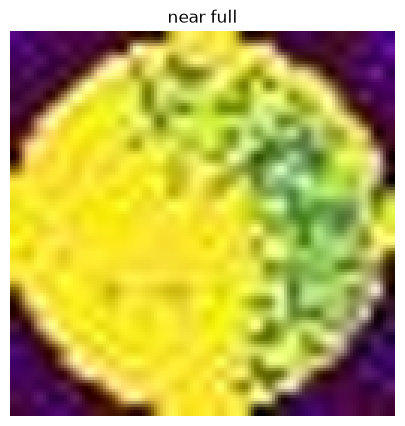

In [12]:
plt.figure(figsize=(5, 5))

plt.imshow(image_normalized)
plt.title(train_df.iloc[0]["label"])
plt.axis("off")

plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf

In [14]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [15]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

In [16]:
train_paths = train_df["image_path"].values
train_labels = train_df["label_id"].values

val_paths = val_df["image_path"].values
val_labels = val_df["label_id"].values

test_paths = test_df["image_path"].values
test_labels = test_df["label_id"].values

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 631
Validation: 135
Test: 136


In [17]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

In [18]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

print("TensorFlow datasets created successfully")

TensorFlow datasets created successfully


In [19]:
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

print("Image preprocessing complete")

Image preprocessing complete


In [20]:
train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Batching and prefetching complete")

Batching and prefetching complete


In [21]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [22]:
from tensorflow.keras import layers, models

NUM_CLASSES = len(class_names)

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 126, 126, 32)     │            896 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 63, 63, 32)       │              0 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 61, 61, 64)       │         18,496 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 30, 30, 64)       │              0 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 28, 28, 128)      │         73,856 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 14, 14, 128)      │              0 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ flatten (Flatten)                 │ (None, 25088)            │              0 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ dense (Dense)                     │ (None, 128)              │      3,211,392 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ dropout (Dropout)                 │ (None, 128)              │              0 │
├───────────────────────────────────┼──────────────────────────┼────────────────┤
│ dense_1 (Dense)                   │ (None, 9)                │          1,161 │
└───────────────────────────────────┴──────────────────────────┴────────────────┘

 Total params: 3,305,801 (12.61 MB)

 Trainable params: 3,305,801 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [ ]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20


C:\Users\nikhi\Documents\Semiconductor-Wafer-Defect-Detection\tf_venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 426ms/step - accuracy: 0.2678 - loss: 1.9517 - val_accuracy: 0.4889 - val_loss: 1.4849
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 498ms/step - accuracy: 0.4596 - loss: 1.4475 - val_accuracy: 0.5556 - val_loss: 1.1690
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 558ms/step - accuracy: 0.5293 - loss: 1.2287 - val_accuracy: 0.6741 - val_loss: 0.8994
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 603ms/step - accuracy: 0.6244 - loss: 1.0653 - val_accuracy: 0.7037 - val_loss: 0.7531
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 563ms/step - accuracy: 0.6910 - loss: 0.8780 - val_accuracy: 0.6444 - val_loss: 0.8114
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 710ms/step - accuracy: 0.7100 - loss: 0.8381 - val_accuracy: 0.7630 - val_loss: 0.6477
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 567ms/step - accuracy: 0.7591 - loss: 0.6803 - val_accuracy: 0.7778 - val_loss: 0.6023
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 577ms/step - accuracy: 0.7797 - loss: 0.6151 - val_accuracy: 0.807

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
model.save("wafer_defect_cnn.keras")

print("Model saved successfully!")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed!")
print("Number of test samples:", len(y_true))

In [ ]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Wafer Defect Classification - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

In [ ]:
wrong_indices = np.where(y_true != y_pred)[0]

print("Total wrong predictions:", len(wrong_indices))
print("Total correct predictions:", np.sum(y_true == y_pred))

In [ ]:
print("Model:", type(model))
print("Test dataset:", type(test_dataset))

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")